URL Dashboard:  https://public.tableau.com/views/TransjakartaDashboard_17757520465640/TransjakartaDashboard?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

# Milestone 2

## i. Perkenalan

Nama : Nadia Syailendra

Batch: CODA-RMT-016

Program ini dibuat sebagai bahan evaluasi Phase 1 pada program CODA Hactiv8.



## ii. Identifikasi Masalah

Topik Permasalahan: Kepadatan penumpang Transjakarta menyebabkan kondisi bus penuh dan tidak nyaman, sehingga muncul asumsi bahwa ketersediaan bus dan kebutuhan penumpang belum optimal.

Problem Statement: Menganalisis rute koridor, arah rute dan jam-jam dimana jumlah penumpang tinggi pada transportasi Transjakarta selama bulan April 2023 

Latar Belakang: Transjakarta merupakan perusahaan transportasi yang menyediakan layanan transportasi umum terintegrasi yang berfokus pada mobilitas yang efisien, aman dan harga yang terjangkau. Kebutuhan penumpang terhadap layanan Transjakarta sangat tinggi, sehingga Transjakarta ingin memastikan operasional yang efisien demi kenyamanan penggunanya. 

Penjabaran Masalah: 

- Rute koridor apa yang memiliki frekuensi tertinggi?
- Rute koridor cenderung ramai di arah pergi atau arah pulang?
- Pada jam berapa jumlah penumpang paling tinggi terjadi (peak hour)?
- Di halte mana paling banyak penumpang naik?
- Bagaimana distribusi usia penumpang transjakarta?
- Apakah rata-rata waktu tempuh saat weekend lebih cepat dari weekday? 

## iii. Data Loading

### Import Library

In [1]:
#Import library yang akan digunakan
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

### Data Source

Dataset ini diambil dari Kaggle yang menunjukkan data dummy transaksi Transjakarta selama bulan April 2023.

Source: https://www.kaggle.com/datasets/dikisahkan/transjakarta-transportation-transaction

### Data Exploration

In [2]:
#Loading data ke dataframe menggunakan pandas
df = pd.read_csv('raw_data.csv', delimiter=',')

In [3]:
#Menampilkan dataframe
df

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37895,ZWEC949B8Q87QG,4685818286724028395,brizzi,Kamila Mahendra,F,2004,6B,Ragunan - MH Thamrin via Semanggi,1.0,P00261,...,106.82309,2,2023-04-21 18:18:37,P00228,SMK 57,-6.290967,106.82365,13.0,2023-04-21 19:55:49,3500.0
37896,YHHK837P6Y95GN,6502902290603767,dki,Titi Siregar,M,1974,9N,Pinang Ranti - Pramuka,1.0,P00064,...,106.88116,1,2023-04-18 21:52:31,P00179,Pinang Ranti,-6.291075,106.88634,2.0,2023-04-18 22:28:22,3500.0
37897,YXPP627N4G95HO,213159426675861,emoney,drg. Zahra Nashiruddin,F,1976,1T,Cibubur - Balai Kota,1.0,B02873P,...,106.81676,12,2023-04-04 10:29:47,B00226P,Buperta Cibubur,-6.370321,106.89628,14.0,2023-04-04 13:27:25,20000.0
37898,RGVK175U2U98UV,377840859133591,emoney,Ana Agustina,M,1976,JAK.13,Tanah Abang - Jembatan Lima,1.0,B02505P,...,106.80954,33,2023-04-15 19:59:26,B01787P,JPO Blok G,-6.188861,106.81135,34.0,2023-04-15 20:27:50,0.0


In [4]:
#Menampilkan 5 data teratas
df.head(5)

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0


In [5]:
#Menampilkan jumlah row dan column pada dataframe
df.shape

(37900, 22)

In [6]:
#Menampilkan summary dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  str    
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  str    
 3   payCardName       37900 non-null  str    
 4   payCardSex        37900 non-null  str    
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  str    
 7   corridorName      35970 non-null  str    
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  str    
 10  tapInStopsName    37900 non-null  str    
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  str    
 15  tapOutStops       35611 non-null  str    
 16  tapOutStopsName   36556 non-null  str    
 17  tapO

In [7]:
#Menampilkan tipe kolom di dataframe
df.dtypes

transID                 str
payCardID             int64
payCardBank             str
payCardName             str
payCardSex              str
payCardBirthDate      int64
corridorID              str
corridorName            str
direction           float64
tapInStops              str
tapInStopsName          str
tapInStopsLat       float64
tapInStopsLon       float64
stopStartSeq          int64
tapInTime               str
tapOutStops             str
tapOutStopsName         str
tapOutStopsLat      float64
tapOutStopsLon      float64
stopEndSeq          float64
tapOutTime              str
payAmount           float64
dtype: object

## iv. Data Cleaning

### Missing Value Checking

In [8]:
#Mengecek missing value
df.isnull().sum()

transID                0
payCardID              0
payCardBank            0
payCardName            0
payCardSex             0
payCardBirthDate       0
corridorID          1257
corridorName        1930
direction              0
tapInStops          1213
tapInStopsName         0
tapInStopsLat          0
tapInStopsLon          0
stopStartSeq           0
tapInTime              0
tapOutStops         2289
tapOutStopsName     1344
tapOutStopsLat      1344
tapOutStopsLon      1344
stopEndSeq          1344
tapOutTime          1344
payAmount           1007
dtype: int64

### Missing Value Handling

Selanjutnya, saya ingin mengetahui kolom mana saja yang perlu di handling dengan melakukan perhitungan persentase missing value terhadap total value dan mengklasifikasikan kolomnya.

In [9]:
#Variable "Check" untuk melihat jumlah null value pada tiap kolom
check = df.isnull().sum()
#Menghitung jumlah total value di dataframe
total = len(df)

#Menggunakan for loop untuk menghitung persentase jumlah null value untuk tiap kolom
for col, null in check.items():
    missing_percentage = (null/total)*100
    #Menggunakan if statement untuk mengklasifikasikan kolom untuk handlingnya
    if missing_percentage == 0:
        print(col,": Tidak perlu handling")
    elif missing_percentage <= 10:
        print(col,": Hapus Baris")
    elif missing_percentage >= 60:
        print(col,": Hapus kolom")
    else:
        print(col, missing_percentage, "%: Consider input NaN or Imputation")



transID : Tidak perlu handling
payCardID : Tidak perlu handling
payCardBank : Tidak perlu handling
payCardName : Tidak perlu handling
payCardSex : Tidak perlu handling
payCardBirthDate : Tidak perlu handling
corridorID : Hapus Baris
corridorName : Hapus Baris
direction : Tidak perlu handling
tapInStops : Hapus Baris
tapInStopsName : Tidak perlu handling
tapInStopsLat : Tidak perlu handling
tapInStopsLon : Tidak perlu handling
stopStartSeq : Tidak perlu handling
tapInTime : Tidak perlu handling
tapOutStops : Hapus Baris
tapOutStopsName : Hapus Baris
tapOutStopsLat : Hapus Baris
tapOutStopsLon : Hapus Baris
stopEndSeq : Hapus Baris
tapOutTime : Hapus Baris
payAmount : Hapus Baris


Kesimpulan:

Hapus baris akan dilakukan untuk kolom-kolom diatas sebagai proses data cleaning.

In [10]:
#Menghapus baris
df = df.dropna(subset=['corridorID', 'corridorName', 'tapInStops', 'tapOutStopsName', 'tapOutStops','tapOutStopsLat', 'tapOutStopsLon', 'stopEndSeq', 'tapOutTime','payAmount'])

### Data Duplicate Checking

In [11]:
#Mengecek data duplikat
df.duplicated().sum()

np.int64(0)

Dataframe tidak ada data duplikat, sehingga data duplicate handling tidak perlu dilakukan.

### Inconsistent Data Handling

In [12]:
#Mengubah tipe data tapInTime dan tapOutTime menjadi date time
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'])

#Mengubah tipe data stopEndSeq menjadi integer, menyesuaikan dengan stopStartSeq
df['stopEndSeq'] = df['stopEndSeq'].astype(int)

## v. Analisis dan Perhitungan

### Nomor 1: Rute koridor apa yang memiliki frekuensi tertinggi?


### Jawaban Nomor 1

In [13]:
#Mencari rute koridor paling ramai berdasarkan jumlah frekuensi 
corridor_freq = df['corridorName'].value_counts().head(10)
print(corridor_freq)


corridorName
Cibubur - Balai Kota                           362
Ciputat - CSW                                  350
Harmoni - Jakarta International Stadium        313
Pulo Gadung - Monas                            311
Kampung Rambutan - Pondok Gede                 305
Kalideres - Bundaran HI via Veteran            299
Rusun Pondok Bambu - Walikota Jakarta Timur    297
Kebayoran Lama - Tanah Abang                   291
Rusun Rawa Bebek - Kodamar                     283
Pasar Minggu - Tanah Abang                     273
Name: count, dtype: int64


<Axes: title={'center': 'Frequency of Transjakarta Corridor Routes'}, ylabel='corridorName'>

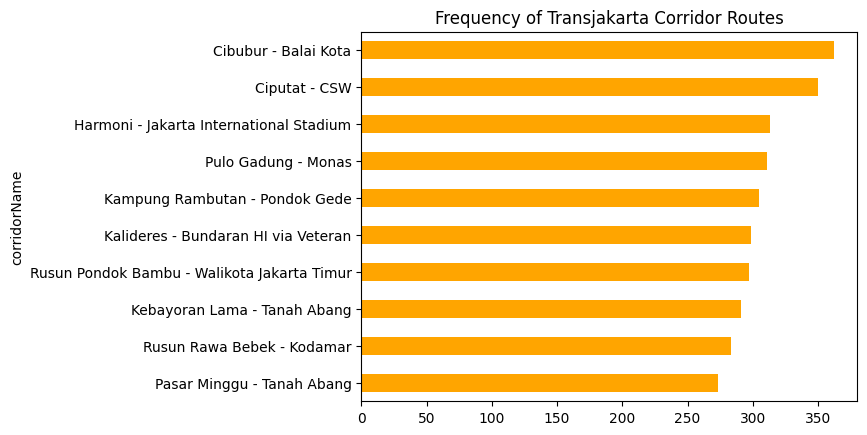

In [14]:
#Memvisualisasikan 15 rute koridor tertinggi menggunakan bar chart
corridor_freq.sort_values().plot(kind='barh', title='Frequency of Transjakarta Corridor Routes', color='orange')

Analisis:

Rute koridor Cibubur - Balai Kota adalah rute koridor yang paling ramai dengan jumlah frekuensi yaitu 362, diikuti dengan rute Ciputat - CSW dengan jumlah frekuensi 350.

Penemuan ini penting karena ada kesamaan menarik dari data ini, yaitu keduanya adalah rute koridor yang daerah paling padat penduduk, yaitu Jakarta Timur dan Tangerang dan destinasi ke daerah pusat atau titik transit (CSW). 

Hal ini mengindikasikan bahwa rute koridor ramai karena adanya kebutuhan mobilitas dari daerah pemukiman menuju pusat kota.

### Nomor 2: Pada jam berapa volume penumpang paling tinggi terjadi (peak hour)?

### Jawaban Nomor 2

In [34]:
#Extract jam dari tapInTime
#extract_hour = df['tapInTime'].dt.hour
extract_hour = pd.to_datetime(df['tapInTime']).dt.hour

#Mencari jam sibuk (peak hour) dengan jumlah transaksi terbanyak
peak_hour = extract_hour.value_counts().sort_index()
print(peak_hour)

tapInTime
5     2809
6     4866
7     2338
8     2397
9     2383
10     256
11     287
12     280
13     296
14     148
15     328
16    2822
17    4624
18    2020
19    2041
20    2028
21    1807
Name: count, dtype: int64


In [38]:
peak_hours_df = df[extract_hour.isin([5, 6, 7, 8, 9, 16, 17, 18, 19, 20, 21])]
top_peak_corridors = (peak_hours_df['corridorName'].value_counts().head(5))
top_peak_stops = (peak_hours_df['tapInStopsName'].value_counts().head(5))

print("--- Top 5 Corridors during Peak Hours ---")
print(top_peak_corridors)

print("\n--- Top 5 Bus Stops during Peak Hours ---")
print(top_peak_stops)

--- Top 5 Corridors during Peak Hours ---
corridorName
Cibubur - Balai Kota                       358
Ciputat - CSW                              335
Harmoni - Jakarta International Stadium    305
Pulo Gadung - Monas                        302
Kampung Rambutan - Pondok Gede             299
Name: count, dtype: int64

--- Top 5 Bus Stops during Peak Hours ---
tapInStopsName
Penjaringan          201
Garuda Taman Mini    179
BKN                  145
BNN LRT              135
Pejaten              130
Name: count, dtype: int64


<Axes: title={'center': 'Peak Hours'}, xlabel='tapInTime'>

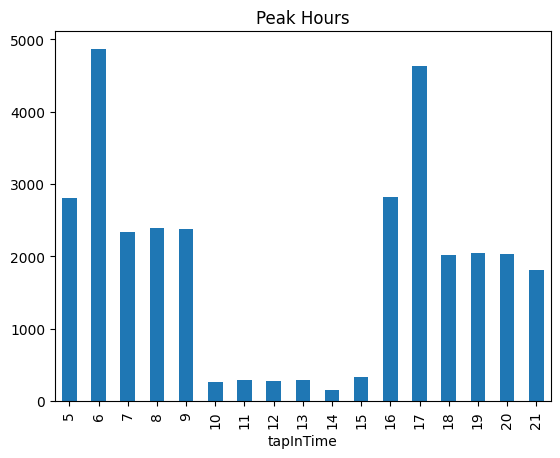

In [16]:
#Memvisualisasikan peak hour menggunakan histogram
peak_hour.plot(kind='bar', title='Peak Hours')

Analisis:

Peak hour terjadi di jam 5 - 9 di pagi hari dan 4 - 9 di malam hari.

Penemuan ini menarik karena peak hour terjadi di rentang waktu yang sama dengan jam masuk dan jam pulang kerja.

Hal ini mengindikasikan bahwa penduduk menggunakan transportasi umum untuk bekerja.

### Nomor 3: Rute koridor cenderung ramai di arah pergi atau arah pulang?


### Jawaban Nomor 3

In [17]:
#Menghitung jumlah frekuensi untuk arah pergi (0) dan pulang (1)
dir_freq = df['direction'].value_counts()
print(dir_freq)

direction
1.0    15881
0.0    15849
Name: count, dtype: int64


In [18]:
#Menghitung selisih arah rute berangkat (go_freq) dan rute balik (back_freq)
go_freq = dir_freq[0]
back_freq = dir_freq[1]
diff_dir = go_freq - back_freq

print('Selisih frekuensi arah rute:',diff_dir)


Selisih frekuensi arah rute: -32


[Text(0, 0, 'Arah Pulang(1)'), Text(0, 1, 'Arah Pergi(0)')]

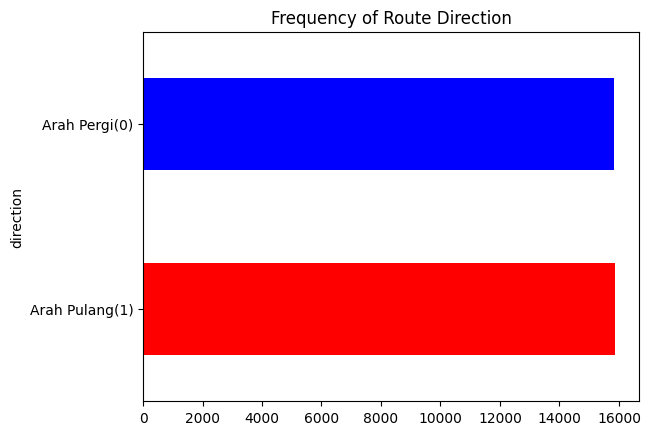

In [19]:
#Memvisualisasikan frekuensi arah berangkat dan pulang menggunakan bar chart
ax = dir_freq.plot(kind='barh', title='Frequency of Route Direction', color=['red','blue'])

#Memberi label ke plot
dir_freq.index = ['Arah Pulang','Arah Pergi']
ax.set_yticklabels(['Arah Pulang(1)','Arah Pergi(0)'])

Analisa:

Perbedaan antara frekuensi transaksi penumpang pada arah berangkat dan arah pulang hanya sedikit, yaitu 29.

Pola ini menunjukkan bahwa penduduk berangkat dan pulang kerja menggunakan moda transportasi yang sama.

### Nomor 4: Di halte mana paling banyak penumpang naik?

### Jawaban Nomor 4

In [20]:
#Menghitung 5 halte dengan jumlah penumpang yang Tap In tertinggi
stops_freq = df['tapInStopsName'].value_counts().head(5)
print(stops_freq)

tapInStopsName
Penjaringan          208
Garuda Taman Mini    180
BKN                  149
BNN LRT              139
Pejaten              133
Name: count, dtype: int64


<Axes: ylabel='tapInStopsName'>

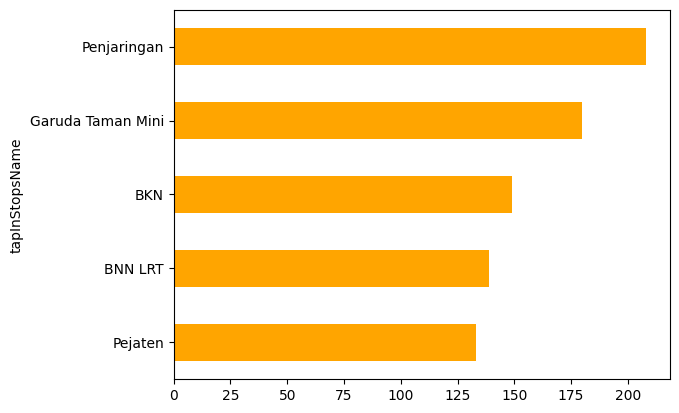

In [21]:
#Memvisualisasikan perhitungan halte diatas menggunakan bar chart
stops_freq.sort_values().plot(kind='barh', color='orange')

Analisis:

Halte Penjaringan memiliki jumlah penumpang yang Tap In paling tinggi yaitu 220 Tap in, diikuti dengan halte Garuda Taman Mini dan halte BKN yang masing-masing memiliki jumlah Tap In 190 dan 157.

Penemuan ini sejalan dengan penemuan pada pertanyaan nomor 1, karena halte Penjaringan, Garuda Taman Mini dan BKN berada di daerah kependudukan tinggi.

Penemuan ini mengindikasikan bahwa halte ini adalah halte terdekat yang menghubungkan pemukiman padat penduduk ke jaringan rute Transjakarta.


### Nomor 5: Bagaimana distribusi usia penumpang Transjakarta?

In [22]:
#Menghitung umur berdasarkan tahun lahir
df['passenger_age'] = 2026 - df['payCardBirthDate']

#Menghitung mean, median, std, skew dan kurtosis untuk melihat distribusi usia penumpang
age_mean = df['passenger_age'].mean()
age_median = df['passenger_age'].median()
age_std = df['passenger_age'].std()
age_skew = df['passenger_age'].skew()
age_kurtosis = df['passenger_age'].kurtosis()

#Menampilkan perhitungan diatas
print('Mean:',age_mean)
print('Median:',age_median)
print('Standard Deviation:',age_std)
print('Skew:',age_skew)
print('Kurtosis:',age_kurtosis)


Mean: 35.789662779703754
Median: 35.0
Standard Deviation: 13.049287755047985
Skew: 0.42371214905223087
Kurtosis: -0.032587085092823376


Analisis:

Distribusi usia penumpang Transjakarta memiliki nilai mean 35,7 dan median 35. Nilai simpangan baku (std) adalah 13 dengan nilai skew 0.42 dan nilai kurtosis -0.03. 

Distribusi ini menunjukkan bahwa penumpang Transjakarta rata-rata berumur 35 -36 tahun dengan angka tengah umur yaitu 35. Distribusinya lumayan konsisten dan simetris (skew kecil) dengan bentuk data mesokurtis yang artinya mendekati distribusi normal.

### Nomor 6: Apakah rata-rata waktu tempuh saat weekend lebih cepat dari weekday?

### Jawaban Nomor 6

Disini saya ingin membandingka dua kelompok yaitu rata-rata waktu tempuh saat weekday dan weekend. Untuk menguji ini, saya akan menggunakan metode dan hipotesis berikut:

Uji hipotesis: T-test (Independen) untuk membandingkan rata-rata antara dua kelompok

Hipotesis 0 (H0) = Tidak ada perbedaan signifikan terhadap rata-rata waktu tempuh pada saat weekday dan weekend

Hipotesis 1 (H1) = Ada perbedaan signifikan terhadap rata-rata waktu tempuh pada kedua saat weekday dan weekend

Tingkat Signifikansi = 5% (0.05)

In [23]:
#Membuat kolom untuk mengelompokkan weekday and weekend dengan tipe format boolean
df['Is_Weekday'] = df['tapInTime'].dt.weekday <= 5

In [24]:
#Membuat kolom waktu tempuh dengan nama "Duration"
df['Duration'] = df['tapOutTime'] - df['tapInTime']

In [25]:
#Membuat kolom waktu tempuh dalam hitungan menit
df['Duration_Mins'] = df['Duration'].dt.total_seconds()/60

In [26]:
#Membuat dataframe untuk masing-masing kelompok weekday dan weekend dengan kolom Duration_Mins
weekday = df[df['Is_Weekday'] == True][['Duration_Mins']]
weekend = df[df['Is_Weekday'] == False][['Duration_Mins']]

#Menampilkan rata-rata waktu tempuh untuk weekday dan weekend
print('Rata-rata waktu tempuh saat weekday:', weekday.mean())
print('Rata-rata waktu tempuh saat weekend:', weekend.mean())

Rata-rata waktu tempuh saat weekday: Duration_Mins    72.270277
dtype: float64
Rata-rata waktu tempuh saat weekend: Duration_Mins    70.779704
dtype: float64


Rata-rata waktu tempuh saat weekday yaitu 72 menit dan saat weekend yaitu 70 menit. Selanjutnya, akan dilakukan perhitungan P-value untuk uji hipotesis. 

In [27]:
#Mencari P-value waktu tempuh dalam menit untuk weekday dan weekend
t_stat, p_val = stats.ttest_ind(weekday['Duration_Mins'], weekend['Duration_Mins'])
print('T-Statistic:',t_stat)
print('P-value:',p_val)

T-Statistic: 2.0401926665402033
P-value: 0.04133940247258707


Analisis:

Dari uji hipotesis yang dilakukan, didapatkan p-value sebesar 0.07.

P-value 0.04 < Tingkat Signifikansi 0.05, artinya H0 ditolak dan H1 diterima.

Ini menunjukkan bahwa ada cukup bukti yang menyimpulkan kalau rata-rata waktu tempuh saat weekend lebih cepat dari pada weekday.

## Save Final data to CSV file

In [28]:
#Menyimpan dataset yang sudah dibersihkan ke file csv untuk diolah ke Tableau
df.to_csv('data_cleaned_Transjakarta.csv', index=False)

## vi. Pengambilan Kesimpulan

### Kesimpulan

Analisis dan perhitungan ini dilakukan untuk mengetahui rute koridor, arah rute dan jam-jam dimana jumlah penumpang ramai pada transportasi Transjakarta selama bulan April 2023.

Kesimpulan yang saya dapat dari dataset ini adalah mayoritas pengguna Transjakarta adalah warga Jabodetabek yang tinggal di daerah padat penduduk yang dalam usia produktif dan menggunakan Transjakarta sebagai moda transportasi pilihan untuk pergi bekerja atau berpergian ke daerah pusat kota pada hari kerja maupun akhir pekan.

Berdasarkan analisis yang saya lakukan, Transjakarta adalah transportasi pilihan warga Jabodetabek yang memberikan layanan yang konsisten dan dapat diandalkan. Ini menandakan Transjakarta berhasil dalam melakukan visi dan misi mereka yaitu menghubungkan kehidupan Jakarta dan menyediakan layanan transportasi yang memudahkan penggunanya.

### Rekomendasi

Penemuan yang didapatkan dari analisis ini dapat dijadikan bahan evaluasi bagi operator Transjakarta untuk hal berikut:
- Perencanaan alokasi bus sesuai dengan rute koridor dan peak hour 
- Penambahaan layanan yang bisa lebih menjangkau ke daerah perumahan yang padat penduduk